# LCZ Consistency LOCATE 2026

This notebook is the starting point for exploratory analysis of SUHII and vegetation metrics.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1 LCZ metadata

In [ ]:
# Import LCZ metadata
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Convert the line-feature DBF table to CSV.
lcz_dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter_3_LOCATE\data\shapefile\lcz_250m.dbf")
out_csv = lcz_dbf_path.with_suffix(".csv")

if not lcz_dbf_path.exists():
    raise FileNotFoundError(f"DBF not found: {lcz_dbf_path}")

table = DBF(str(lcz_dbf_path), load=True, raw=False)
lcz_metadata = pd.DataFrame(iter(table))
lcz_metadata= lcz_metadata[["hex_id", "gridcode_2"]]

# Rename gridcode_2 to lcz
lcz_metadata = lcz_metadata.rename(columns={"gridcode_2": "lcz"})

# display the count the total number of rows and unique hex_id values
num_rows = len(lcz_metadata)
unique_hex_ids = lcz_metadata["hex_id"].nunique()

print(f"Total rows: {num_rows}")
print(f"Unique hex_id values: {unique_hex_ids}")

# Display the first few rows to verify
print(lcz_metadata.head())

# 2 Land cover

In [23]:
# Load the Land cover per LCZ data
df_land_cover = pd.read_csv('../data/csv/00_landCover_tabulateArea_csv.csv', low_memory=False)

# Rename "Id" to "hex_id"
df_land_cover.rename(columns={'Id': 'hex_id'}, inplace=True)

# Create a new column for the total area
df_land_cover['total_area'] = df_land_cover[
    ['VALUE_1', 'VALUE_2', 'VALUE_3', 'VALUE_4', 'VALUE_5', 'VALUE_6', 'VALUE_7', 'VALUE_8']
].sum(axis=1)

for i in range(1, 9):
    df_land_cover[f'VALUE_{i}_per'] = df_land_cover[f'VALUE_{i}'] * 100 / df_land_cover['total_area']

# Rename
rename_dict = {
    'VALUE_1_per': 'per_low_infra',
    'VALUE_2_per': 'per_high_infra',
    'VALUE_3_per': 'per_grass',
    'VALUE_4_per': 'per_shrub',
    'VALUE_5_per': 'per_tree',
    'VALUE_6_per': 'per_water',
    'VALUE_7_per': 'per_dry_grass',
    'VALUE_8_per': 'per_bare'
}

df_land_cover.rename(columns=rename_dict, inplace=True)

# Keep only requested columns
keep_cols = [
    'hex_id',
    'per_low_infra',
    'per_high_infra',
    'per_grass',
    'per_shrub',
    'per_tree',
    'per_water',
    'per_dry_grass',
    'per_bare'
]

# Subset only existing columns to avoid KeyError
df_land_cover = df_land_cover[[c for c in keep_cols if c in df_land_cover.columns]]


In [24]:
# Merge the land cover data with the LCZ metadata
df_land_cover_metadata = pd.merge(df_land_cover, lcz_metadata, on='hex_id', how='left')

# Export the cleaned DataFrame to a new CSV file
df_land_cover_metadata.to_csv('../data/csv/01_landCover_exported_csv.csv', index=False)

# Display the first few rows to verify
print(df_land_cover_metadata.head())


   hex_id  per_low_infra  per_high_infra  per_grass  per_shrub  per_tree  \
0   21447       0.000000         0.00000    0.00000   0.000000  0.000000   
1   21449       0.000000         0.00000    0.00000   0.000000  0.000000   
2   21451       0.000000         0.00000    0.00000   0.000000  0.000000   
3   21452       0.000000         0.00000    0.00000   0.000000  0.000000   
4   21453       2.111035         1.60055    3.75535   0.710677  0.164412   

    per_water  per_dry_grass  per_bare  lcz  
0  100.000000       0.000000       0.0   17  
1  100.000000       0.000000       0.0   17  
2  100.000000       0.000000       0.0   17  
3  100.000000       0.000000       0.0   17  
4   91.098207       0.559769       0.0   17  


# 3 Urban surface parameters

## 3.2 3D-wall area
### 3.2.1 Exposed wall area

In [1]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Convert the line-feature DBF table to CSV.
dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\big_files\bldg_topology\polygon\bldg_line_JOINED_filtered_intersect_lcz.dbf")
out_csv = dbf_path.with_suffix(".csv")

if not dbf_path.exists():
    raise FileNotFoundError(f"DBF not found: {dbf_path}")

table = DBF(str(dbf_path), load=True, raw=False)
df_wall_area = pd.DataFrame(iter(table))
df_wall_area = df_wall_area[["hex_id", "abs_height", "length"]]

# Rename gridcode_2 to lcz
#df_wall_area = df_wall_area.rename(columns={"gridcode_2": "lcz"})

# Create new columns
df_wall_area["abs_height_m"] = df_wall_area["abs_height"] / 100
df_wall_area["wall_area_m2"] = df_wall_area["abs_height_m"] * df_wall_area["length"]


In [2]:
# Sum wall_area_m2 by hex_id.
df_bldg_wall_area_by_hex = df_wall_area.groupby(["hex_id"], as_index=False)["wall_area_m2"].sum()
df_bldg_wall_area_by_hex = df_bldg_wall_area_by_hex.sort_values(["hex_id"]).reset_index(drop=True)

# Count the number of rows and unique hex_id values
num_rows = len(df_bldg_wall_area_by_hex)
num_unique_hex_ids = df_bldg_wall_area_by_hex['hex_id'].nunique()
print(f"File: {dbf_path.name} - Rows: {num_rows}, Unique hex_id: {num_unique_hex_ids}")

print(df_bldg_wall_area_by_hex.head())

File: bldg_line_JOINED_filtered_intersect_lcz.dbf - Rows: 15070, Unique hex_id: 15070
   hex_id  wall_area_m2
0   21455  14466.280465
1   21457  21312.966116
2   21780  11511.289654
3   21782  19020.164493
4   21784  21454.239993


### 3.2.2 Plan area (Roof area)
1. Use `bldg_height_highest_filtered.shp` as the input layer.

2. Intersect the building layer with the LCZ hexagon layer and save the output as:
   `bldg_height_highest_filtered_intersect_lcz.shp`

3. Create a new field named `plan_area` with the data type **Double**.

4. Use **Calculate Geometry** to compute the area of each intersected polygon in **square metres** and store the result in the `plan_area` field.

In [3]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Load the DBF table and keep only the requested columns.
dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\big_files\wall_area_rescale\bldg_height_highest_filtered_intersect_lcz.dbf")
filtered_csv = dbf_path.with_name(f"{dbf_path.stem}_selected_columns.csv")

table = DBF(str(dbf_path), ignore_missing_memofile=True, load=True)
df_plan_area = pd.DataFrame(iter(table))

# Rename gridcode_2 to lcz
df_plan_area = df_plan_area.rename(columns={"gridcode_2": "lcz"})

df_plan_area = df_plan_area[["hex_id", "plan_area"]]

In [4]:
# Sum plan_area by hex_id and lcz.
df_plan_area_by_hex = df_plan_area.groupby(["hex_id"], as_index=False)["plan_area"].sum()
df_plan_area_by_hex = df_plan_area_by_hex.sort_values(["hex_id"]).reset_index(drop=True)

print(df_plan_area_by_hex.head())

   hex_id     plan_area
0   21455   7289.594694
1   21457  10379.546688
2   21780   8119.796063
3   21782  11880.254418
4   21784  14821.082583


## 3.3 Mean building height

In [5]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Load the DBF table and keep only the requested columns.
dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\big_files\bldg_height\bldg_height_lcz_intersect.dbf")
filtered_csv = dbf_path.with_name(f"{dbf_path.stem}_selected_columns.csv")

table = DBF(str(dbf_path), ignore_missing_memofile=True, load=True)
df_bldg_height = pd.DataFrame(iter(table))

# Rename gridcode_2 to lcz
#df_bldg_height = df_bldg_height.rename(columns={"gridcode_2": "lcz"})

df_bldg_height = df_bldg_height[["hex_id",  "height"]]

In [6]:
# Mean bldg_height by hex_id and lcz.
df_bldg_height_by_hex = df_bldg_height.groupby(["hex_id"], as_index=False)["height"].mean()
df_bldg_height_by_hex = df_bldg_height_by_hex.sort_values(["hex_id"]).reset_index(drop=True)

print(df_bldg_height_by_hex.head())

   hex_id    height
0   21455  6.767000
1   21457  6.316522
2   21780  4.390600
3   21782  4.333494
4   21784  5.395397


## 3.4 Sky View Factor

In [7]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

svf_dir = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter_3_LOCATE\data\dbf\svf")


for dbf_path in svf_dir.glob("*.dbf"):
    if dbf_path.name.endswith(".lock"):
        continue

    table = DBF(str(dbf_path), ignore_missing_memofile=True, load=True)
    df_svf = pd.DataFrame(iter(table))

    df_svf_by_hex = df_svf.rename(columns={"MEAN": "svf"})[["hex_id", "svf"]]

# Count the number of rows and unique hex_id values
    num_rows = len(df_svf_by_hex)
    num_unique_hex_ids = df_svf_by_hex['hex_id'].nunique()
    print(f"File: {dbf_path.name} - Rows: {num_rows}, Unique hex_id: {num_unique_hex_ids}")

print(df_svf_by_hex.head())

File: svf_mosaic.dbf - Rows: 20166, Unique hex_id: 20166
   hex_id      svf
0   21447  1.00000
1   21449  1.00000
2   21451  1.00000
3   21452  1.00000
4   21453  0.99691


## 3.5 Merge urban surface parameters

In [20]:
# Merge all DataFrames on 'hex_id'
df_urban_surface_paramaters = (
    lcz_metadata
    .merge(df_svf_by_hex, on="hex_id", how="outer")
    .merge(df_plan_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_wall_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_height_by_hex, on="hex_id", how="outer")
)
# Nan values to 0 for wall_area_m2 and plan_area, since missing values likely indicate no building.
cols = ["svf", "height", "wall_area_m2", "plan_area"]

df_urban_surface_paramaters[cols] = df_urban_surface_paramaters[cols].fillna(0) 

# Export the cleaned DataFrame to a new CSV file
df_urban_surface_paramaters.to_csv('../data/csv/02_urbanSurfaceParameters_exported_csv.csv', index=False)

# Display the first few rows to verify
print(df_urban_surface_paramaters.head())

   hex_id  lcz      svf  plan_area  wall_area_m2  height
0   21447   17  1.00000        0.0           0.0     0.0
1   21449   17  1.00000        0.0           0.0     0.0
2   21451   17  1.00000        0.0           0.0     0.0
3   21452   17  1.00000        0.0           0.0     0.0
4   21453   17  0.99691        0.0           0.0     0.0


# 4 Merge Land cover with Urban surface parameters
## 4.1 Data preparation

In [27]:
# Merge all DataFrames on 'hex_id'
df_landCover_builtUp = (
    lcz_metadata
    .merge(df_land_cover, on="hex_id", how="outer")
    .merge(df_svf_by_hex, on="hex_id", how="outer")
    .merge(df_plan_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_wall_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_height_by_hex, on="hex_id", how="outer")
)

# Nan values to 0 for wall_area_m2 and plan_area, since missing values likely indicate no building.
cols = ["per_low_infra", "per_high_infra", "per_grass", "per_shrub", "per_tree","per_water", "per_dry_grass","per_bare",
        "svf", "height", "wall_area_m2", "plan_area"]

df_landCover_builtUp[cols] = df_landCover_builtUp[cols].fillna(0) 

# Create a new column named "wall_plan_area_m2" by adding "wall_area_m2" and "plan_area"
df_landCover_builtUp["wall_plan_area_m2"] = df_landCover_builtUp["wall_area_m2"] + df_landCover_builtUp["plan_area"]

# Display the number of rows and unique hex_id values
num_rows = len(df_landCover_builtUp)
num_unique_hex_ids = df_landCover_builtUp['hex_id'].nunique()
print(f"Rows: {num_rows}, Unique hex_id: {num_unique_hex_ids}")

# Display the first few rows
df_landCover_builtUp.head()

Rows: 20166, Unique hex_id: 20166


,hex_id,lcz,per_low_infra,per_high_infra,per_grass,per_shrub,per_tree,per_water,per_dry_grass,per_bare,svf,plan_area,wall_area_m2,height,wall_plan_area_m2
0,21447,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
1,21449,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
2,21451,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
3,21452,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
4,21453,17,2.111035,1.60055,3.75535,0.710677,0.164412,91.098207,0.559769,0.0,0.99691,0.0,0.0,0.0,0.0


In [28]:
# Sum per_grass with per_dry_grass to create a new column named "per_total_grass"
df_landCover_builtUp["per_total_grass"] = df_landCover_builtUp["per_grass"] + df_landCover_builtUp["per_dry_grass"]

# Sum per_low_infra with per_high_infra to create a new column named "per_impervious"
df_landCover_builtUp["per_impervious"] = df_landCover_builtUp["per_low_infra"] + df_landCover_builtUp["per_high_infra"]

# Count the number of rows and unique hex_id values
num_rows = len(df_landCover_builtUp)
unique_hex_ids = df_landCover_builtUp["hex_id"].nunique()
print(f"Rows: {num_rows}, Unique hex_id: {unique_hex_ids}")

# Save the merged dataset for later use
df_landCover_builtUp.to_csv('../data/csv/03_landCover_builtUp_exported_csv.csv', index=False)

Rows: 20166, Unique hex_id: 20166


## 4.2 Plots
### 4.2.1 Level 1 Summary F1 metric

C:\Users\percy\AppData\Local\Temp\ipykernel_37576\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_37576\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_37576\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_37576\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

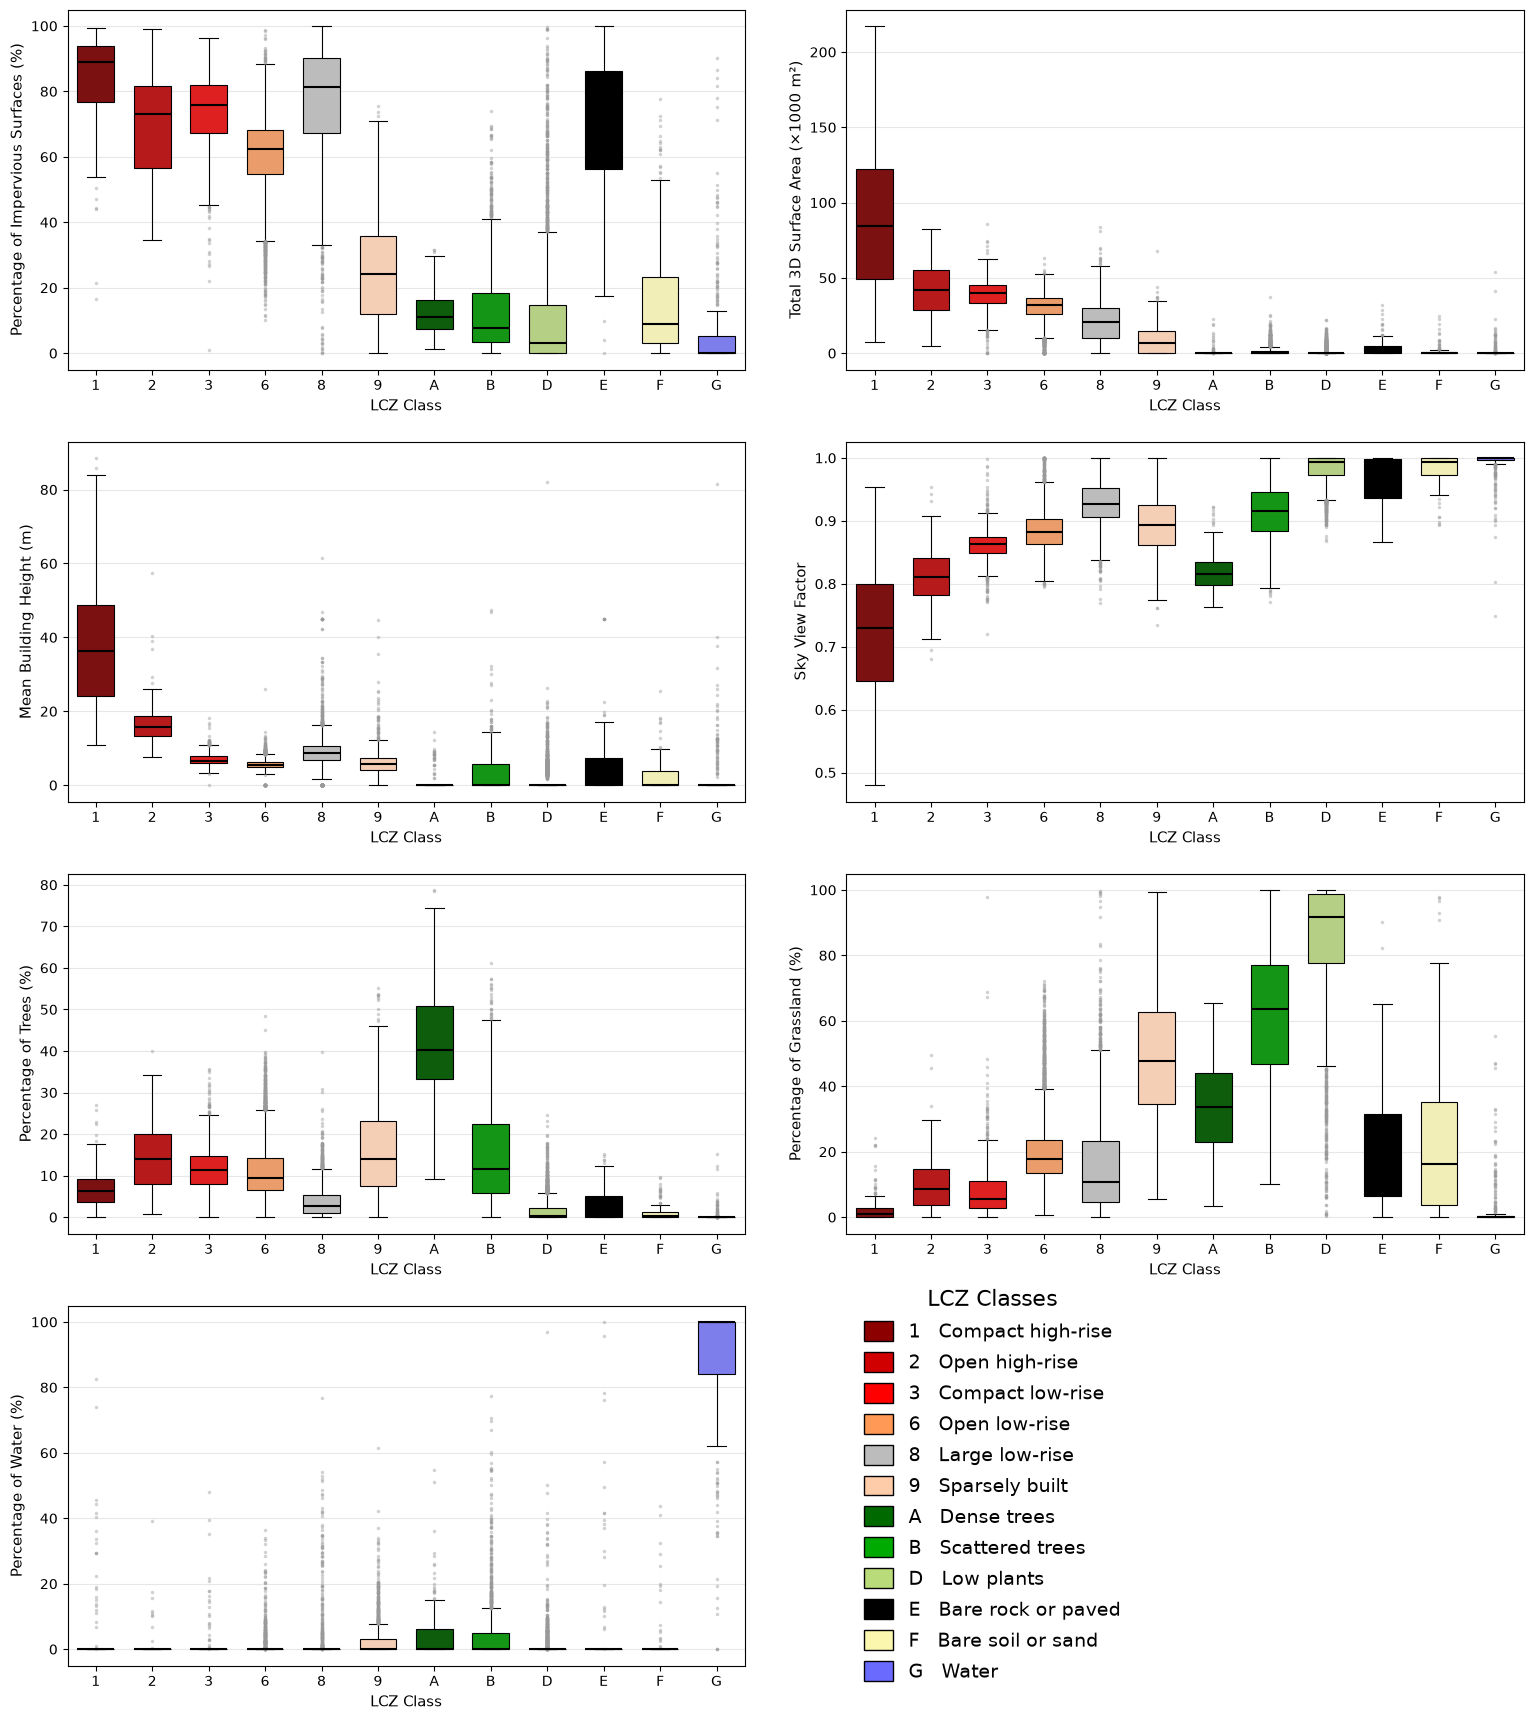

Saved: C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures\lcz_boxplots_panel.png


In [92]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Read data
# ------------------------------------------------------------------
df_landCover_builtUp_plot = pd.read_csv(
    '../data/csv/03_landCover_builtUp_exported_csv.csv'
)

output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------
# Variables
# ------------------------------------------------------------------
variables = [
    'per_impervious',
    'per_total_grass',
    'per_tree',
    'svf',
    'height',
    'wall_plan_area_m2',
    'per_water'
]

y_label_map = {
    'per_impervious': 'Percentage of Impervious Surfaces (%)',
    'per_total_grass': 'Percentage of Grassland (%)',
    'per_tree': 'Percentage of Trees (%)',
    'per_water': 'Percentage of Water (%)',
    'svf': 'Sky View Factor',
    'height': 'Mean Building Height (m)',
    'wall_plan_area_m2': 'Total 3D Surface Area (×1000 m²)'
}

lcz_label_map = {
    1: '1',
    2: '2',
    3: '3',
    6: '6',
    8: '8',
    9: '9',
    11: 'A',
    12: 'B',
    14: 'D',
    15: 'E',
    16: 'F',
    17: 'G'
}

color_map = {
    1: '#8c0000',
    2: '#d10000',
    3: '#ff0000',
    6: '#ff9955',
    8: '#bcbcbc',
    9: '#ffccaa',
    11: '#006a00',
    12: '#00aa00',
    14: '#b9db79',
    15: '#000000',
    16: '#fbf7ae',
    17: '#6a6aff'
}

# ------------------------------------------------------------------
# Prepare dataframe
# ------------------------------------------------------------------
plot_df = df_landCover_builtUp_plot.copy()

plot_df['lcz_label'] = plot_df['lcz'].map(lcz_label_map)
plot_df = plot_df.dropna(subset=['lcz_label'])

plot_df['wall_plan_area_m2_plot'] = (
    plot_df['wall_plan_area_m2'] / 1000
)

palette = {
    lcz_label_map[k]: color_map[k]
    for k in lcz_label_map
}

order = [lcz_label_map[k] for k in sorted(lcz_label_map)]

# ------------------------------------------------------------------
# Boxplot function
# ------------------------------------------------------------------
def make_boxplot(ax, var):

    y_var = (
        'wall_plan_area_m2_plot'
        if var == 'wall_plan_area_m2'
        else var
    )

    sns.boxplot(
        data=plot_df,
        x='lcz_label',
        y=y_var,
        order=order,
        palette=palette,
        linewidth=0.8,
        width=0.65,
        ax=ax,

        flierprops=dict(
            marker='o',
            markerfacecolor='0.6',
            markeredgecolor='none',
            markersize=2.5,
            alpha=0.45
        ),

        medianprops=dict(
            color='black',
            linewidth=1.5
        )
    )

    ax.set_xlabel('LCZ Class', fontsize=11)
    ax.set_ylabel(y_label_map[var], fontsize=11)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    ax.grid(axis='y', alpha=0.3)

# ------------------------------------------------------------------
# Create figure
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16,18)
)

axes = axes.flatten()

panel_order = [
    'per_impervious',
    'wall_plan_area_m2',
    'height',
    'svf',
    'per_tree',
    'per_total_grass',
    'per_water'
]

# ------------------------------------------------------------------
# Draw boxplots
# ------------------------------------------------------------------
for ax, var in zip(axes[:7], panel_order):
    make_boxplot(ax, var)

# ------------------------------------------------------------------
# Legend panel
# ------------------------------------------------------------------
legend_ax = axes[7]
legend_ax.axis('off')

legend_items = [
    (1, 'Compact high-rise'),
    (2, 'Open high-rise'),
    (3, 'Compact low-rise'),
    (6, 'Open low-rise'),
    (8, 'Large low-rise'),
    (9, 'Sparsely built'),
    (11, 'Dense trees'),
    (12, 'Scattered trees'),
    (14, 'Low plants'),
    (15, 'Bare rock or paved'),
    (16, 'Bare soil or sand'),
    (17, 'Water')
]

handles = [
    Patch(
        facecolor=color_map[lcz],
        edgecolor='black',
        label=f"{lcz_label_map[lcz]}   {name}"
    )
    for lcz, name in legend_items
]

legend_ax.legend(
    handles=handles,
    title='LCZ Classes',
    loc='center left',
    frameon=False,
    fontsize=14,
    title_fontsize=16,
    handlelength=1.5,
    handleheight=1.2
)

# ------------------------------------------------------------------
# Better spacing
# ------------------------------------------------------------------
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.98,
    bottom=0.06,
    wspace=0.15,
    hspace=0.20
)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
panel_path = os.path.join(
    output_dir,
    'lcz_boxplots_panel.png'
)

plt.savefig(
    panel_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved: {panel_path}')

In [93]:
# Summary statistics by LCZ
summary = (
    plot_df
    .groupby('lcz')[variables]
    .agg(['mean', 'median', 'std'])
)

print(summary)

    per_impervious                       per_total_grass             \
              mean     median        std            mean     median   
lcz                                                                   
1        83.749847  89.105365  15.427683        2.885577   0.878736   
2        70.069468  73.196126  16.153357       10.823242   8.737604   
3        73.902249  75.725656  12.046645        8.364365   5.559775   
6        60.782893  62.386445  11.338694       19.889808  17.820951   
8        76.910353  81.329970  17.507257       15.827223  10.680445   
9        24.557623  24.065439  15.475770       49.454115  47.827655   
11       12.328771  11.124801   6.363354       33.360822  33.611592   
12       12.987301   7.691572  13.600252       61.544012  63.565931   
14       11.221636   3.005153  17.608370       84.508505  91.815661   
15       68.034910  68.042193  21.217287       20.809277  17.790377   
16       18.247830   8.897948  21.191288       24.737122  16.142162   
17    

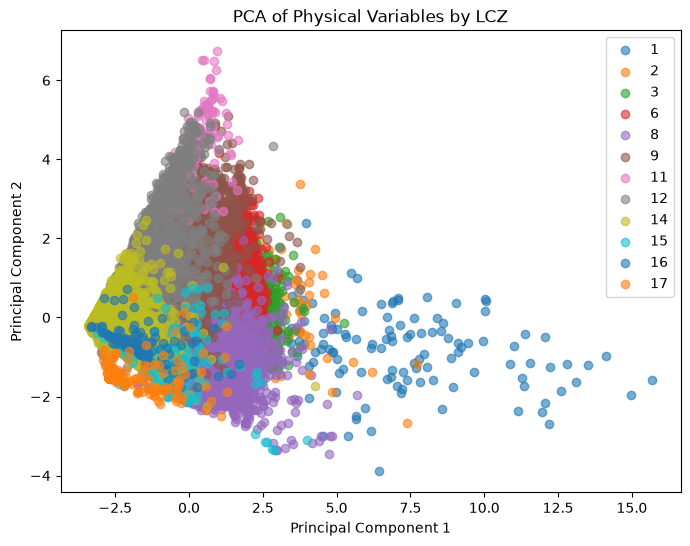

In [94]:
# PCA Visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = plot_df[variables]

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for cls in sorted(plot_df['lcz'].unique()):
    mask = plot_df['lcz'] == cls
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=cls,
        alpha=0.6
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Physical Variables by LCZ')
plt.legend()
plt.show()

In [95]:
# Random Forest Classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = plot_df[variables]
y = plot_df['lcz']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.75      0.75      0.75        40
           2       0.50      0.48      0.49        23
           3       0.71      0.39      0.50       252
           6       0.87      0.92      0.90      2431
           8       0.81      0.80      0.80       965
           9       0.53      0.48      0.50       509
          11       0.58      0.62      0.60        45
          12       0.57      0.52      0.55       484
          14       0.81      0.89      0.85      1112
          15       0.31      0.10      0.15        42
          16       0.73      0.59      0.65        41
          17       0.92      0.94      0.93       106

    accuracy                           0.79      6050
   macro avg       0.67      0.62      0.64      6050
weighted avg       0.78      0.79      0.78      6050



In [96]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score
)

import matplotlib.pyplot as plt

####################################################
# Data
####################################################
X = plot_df[variables]
y = plot_df["lcz"]

####################################################
# Repeated random split
####################################################
n_runs = 30

sss = StratifiedShuffleSplit(
    n_splits=n_runs,
    test_size=0.30,
    random_state=42
)

results = []

built_up_classes = [
    "LCZ1","LCZ2","LCZ3","LCZ4","LCZ5",
    "LCZ6","LCZ7","LCZ8","LCZ9","LCZ10",
    1,2,3,4,5,6,7,8,9,10
]

for train_idx, test_idx in sss.split(X, y):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf = RandomForestClassifier(
        random_state=None,
        n_estimators=200
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    ###################################
    # Overall Accuracy
    ###################################
    oa = accuracy_score(y_test, pred)

    ###################################
    # Weighted Overall Accuracy
    # (Balanced Accuracy)
    ###################################
    oaw = balanced_accuracy_score(y_test, pred)

    ###################################
    # Built-up Overall Accuracy
    ###################################
    mask = y_test.isin(built_up_classes)

    oabu = accuracy_score(
        y_test[mask],
        pred[mask]
    )

    ###################################
    # Recall for every LCZ
    ###################################
    recalls = recall_score(
        y_test,
        pred,
        labels=np.unique(y),
        average=None
    )

    row = {
        "OA": oa,
        "OAbu": oabu,
        "OAw": oaw
    }

    for cls, rec in zip(np.unique(y), recalls):
        row[str(cls)] = rec

    results.append(row)

results = pd.DataFrame(results)

C:\Users\percy\AppData\Local\Temp\ipykernel_37576\923706880.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_37576\923706880.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


Saved: C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures\level1_accuracy_F1_metric.png


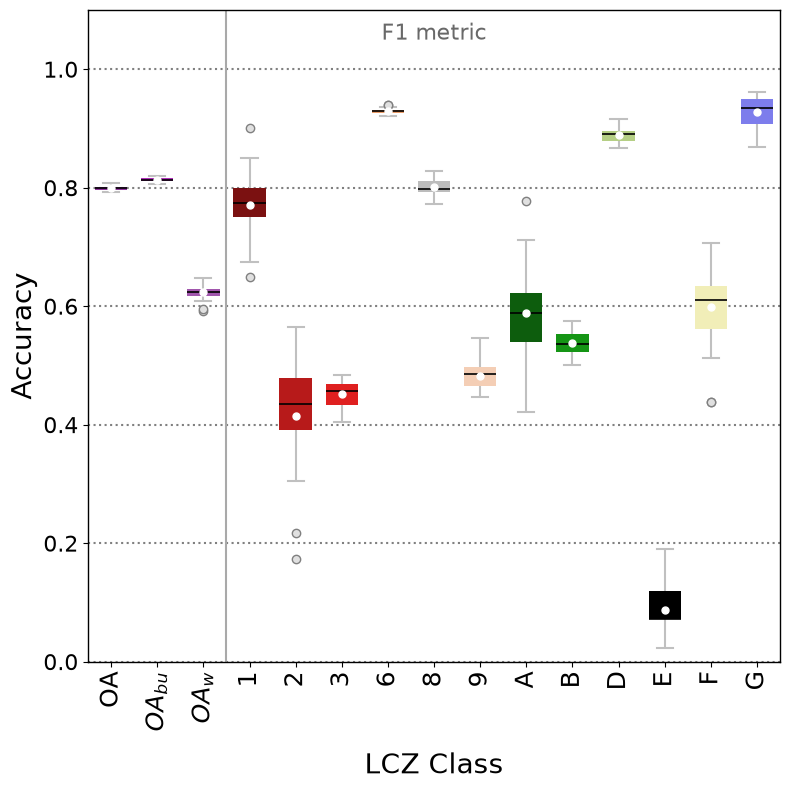

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# Rename LCZ columns (if they are integers)
# ==========================================================
results = results.rename(columns={
    "11": "A",
    "12": "B",
    "14": "D",
    "15": "E",
    "16": "F",
    "17": "G"
})

# ==========================================================
# LCZ columns
# ==========================================================
lcz_columns = [
    c for c in results.columns
    if c not in ["OA", "OAbu", "OAw"]
]

# ==========================================================
# Create plotting dataframe
# ==========================================================
plot_df = pd.DataFrame()

# Overall Accuracy metrics
for metric in ["OA", "OAbu", "OAw"]:
    temp = pd.DataFrame({
        "Class": metric,
        "Accuracy": results[metric]
    })
    plot_df = pd.concat(
        [plot_df, temp],
        ignore_index=True
    )

# LCZ metrics
for c in lcz_columns:
    temp = pd.DataFrame({
        "Class": str(c),
        "Accuracy": results[c]
    })
    plot_df = pd.concat(
        [plot_df, temp],
        ignore_index=True
    )

# ==========================================================
# Colour palette
# ==========================================================
palette = {
    # Overall Accuracy
    "OA": "#9c27b0",
    "OAbu": "#c218d0",
    "OAw": "#ab47bc",

    # Urban LCZs
    "1": "#8c0000",
    "2": "#d10000",
    "3": "#ff0000",
    "6": "#ff9955",
    "8": "#bcbcbc",
    "9": "#ffccaa",

    # Natural LCZs
    "A": "#006a00",
    "B": "#00aa00",
    "D": "#b9db79",
    "E": "#000000",
    "F": "#fbf7ae",
    "G": "#6a6aff"
}

# ==========================================================
# Order of classes
# ==========================================================
order = [
    "OA", "OAbu", "OAw",
    "1", "2", "3", "6", "8", "9",
    "A", "B", "D", "E", "F", "G"
]

# ==========================================================
# Plot
# ==========================================================
# Updated figure size to match Level 0 proportions
plt.figure(figsize=(8, 8))

ax = sns.boxplot(
    data=plot_df,
    x="Class",
    y="Accuracy",
    order=order,
    palette=palette,
    width=0.7,  # Matched Level 0 width
    
    showmeans=True,

    # Mean properties from Level 0
    meanprops=dict(
        marker='o',
        markerfacecolor='white',
        markeredgecolor='white',
        markersize=5
    ),

    # Median properties from Level 0
    medianprops=dict(
        color='black',
        linewidth=1.2
    ),

    # Whisker properties from Level 0
    whiskerprops=dict(
        color='silver',
        linewidth=1.5
    ),

    # Cap properties from Level 0
    capprops=dict(
        color='silver',
        linewidth=1.5
    ),

    # Box properties (removing edge lines to match Level 0)
    boxprops=dict(
        edgecolor='none', 
        alpha=1
    ),

    # Outlier/flier properties from Level 0
    flierprops=dict(
        marker='o',
        markerfacecolor='#e0e0e0',
        markeredgecolor='grey',
        markersize=6,
        alpha=1
    )
)

# ==========================================================
# Formatting
# ==========================================================
# Vertical line separating OA and LCZ metrics
ax.axvline(
    2.5,
    color='darkgray',
    linewidth=1.5
)

# Y-axis bounds and explicit ticks
ax.set_ylim(0.0, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Axis labels with Level 0 font sizing and padding
ax.set_ylabel("Accuracy", fontsize=20)
ax.set_xlabel("LCZ Class", fontsize=20, labelpad=15)

# LaTeX formatting for the x-tick labels
ax.set_xticklabels([
    "OA", r"$OA_{bu}$", r"$OA_w$",
    "1", "2", "3", "6", "8", "9",
    "A", "B", "D", "E", "F", "G"
])

# Rotate and size x-ticks
plt.setp(
    ax.get_xticklabels(),
    rotation=90,
    fontsize=18
)

# Size y-ticks
ax.tick_params(
    axis='y',
    labelsize=16
)

# Horizontal grid lines behind the plot
ax.yaxis.grid(
    True,
    linestyle=':',
    linewidth=1.5,
    color='grey'
)
ax.set_axisbelow(True)

# Remove seaborn default trimming
sns.despine()

# ==========================================================
# Add full black border around plot (all spines)
# ==========================================================
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

# Title inside plot (adjusted x-coordinate for center of 15 items)
ax.text(
    7,
    1.05,
    "F1 metric",
    fontsize=16,
    color="dimgray",
    ha="center"
)

plt.tight_layout()
# Save figure
output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "level1_accuracy_F1_metric.png")
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)
print(f"Saved: {output_path}")

plt.show()

### 4.2.2 Level 0 Summary F1 metric

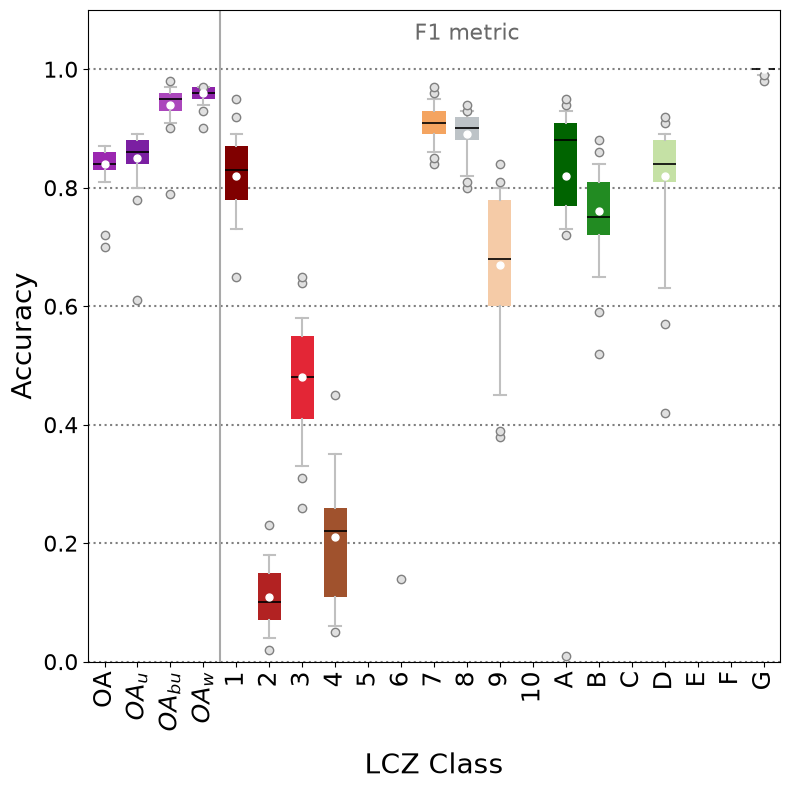

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the summary statistics
# Ensure the CSV file is in the same directory as this script
df = pd.read_csv('../data/csv/04_level0_F1_score_csv.csv', low_memory=False)

# 2. Define the full list of classes (including the empty ones on the X-axis)
all_classes = [
    'OA', 'OA_u', 'OA_bu', 'OA_w', '1', '2', '3', '4', '5', 
    '6', '7', '8', '9', '10', 'A', 'B', 'C', 'D', 'E', 'F', 'G'
]

# 3. Define the approximate colors for the boxes based on the original image
colors = {
    'OA': '#9b27b0', 'OA_u': '#7b1fa2', 'OA_bu': '#ab47bc', 'OA_w': '#8e24aa',
    '1': '#800000', '2': '#b22222', '3': '#e32636', '4': '#a0522d',
    '7': '#f4a460', '8': '#bdc3c7', '9': '#f5cba7',
    'A': '#006400', 'B': '#228b22', 'D': '#c5e1a5', 'G': '#191970'
}

valid_stats = []
valid_positions = []
box_colors = []

# Initialize the plot
fig, ax = plt.subplots(figsize=(8, 8))

# 4. Process the data into the dictionary format required by matplotlib's bxp
for i, cls in enumerate(all_classes, start=1):
    row = df[df['Class'] == cls]
    
    if not row.empty:
        r = row.iloc[0]
        
        # Parse outliers from the comma-separated string
        outliers = []
        if pd.notna(r['Outliers']):
            outliers = [float(x.strip()) for x in str(r['Outliers']).split(',')]
        
        # Special handling for Class 6 (only has an outlier, no box structure)
        if pd.isna(r['Q1']):
            ax.plot([i] * len(outliers), outliers, 'o', markerfacecolor='#e0e0e0', 
                    markeredgecolor='grey', markersize=6)
        else:
            # Prepare the stats dictionary for standard boxes
            stat = {
                'label': cls,
                'whislo': r['Lower_Whisker'],
                'q1': r['Q1'],
                'med': r['Median'],
                'q3': r['Q3'],
                'whishi': r['Upper_Whisker'],
                'fliers': outliers,
                'mean': r['Mean'] if pd.notna(r['Mean']) else np.nan
            }
            
            valid_stats.append(stat)
            valid_positions.append(i)
            box_colors.append(colors.get(cls, 'white'))

# 5. Draw the boxplots using the summary statistics
bplot = ax.bxp(valid_stats, positions=valid_positions, showmeans=True, patch_artist=True, widths=0.7,
               meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'white', 'markersize':5},
               medianprops={'color':'black', 'linewidth': 1.2},
               flierprops={'marker':'o', 'markerfacecolor':'#e0e0e0', 'markeredgecolor':'grey', 'markersize':6},
               whiskerprops={'color': 'silver', 'linewidth': 1.5},
               capprops={'color': 'silver', 'linewidth': 1.5})

# Apply the designated colors to the boxes and remove borders
for patch, color in zip(bplot['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('none')

# 6. Recreate the visual styling, grids, and labels

# Y-axis bounds and ticks
ax.set_ylim(0.0, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('Accuracy', fontsize=20)
ax.tick_params(axis='y', labelsize=16)

# Horizontal grid lines (set behind the plots)
ax.yaxis.grid(True, linestyle=':', linewidth=1.5, color='grey')
ax.set_axisbelow(True)

# Vertical separation line (between OA_w at position 4 and class 1 at position 5)
ax.axvline(x=4.5, color='darkgray', linewidth=1.5)

# X-axis labels with LaTeX formatting for subscripts
x_labels = [
    'OA', r'$OA_u$', r'$OA_{bu}$', r'$OA_w$', '1', '2', '3', '4', '5', 
    '6', '7', '8', '9', '10', 'A', 'B', 'C', 'D', 'E', 'F', 'G'
]
ax.set_xticks(range(1, 22))
ax.set_xticklabels(x_labels, rotation=90, fontsize=18)
ax.set_xlabel('LCZ Class', fontsize=20, labelpad=15)

# Top floating text
ax.text(12, 1.05, 'F1 metric', fontsize=16, color='dimgrey', ha='center')

# Final layout adjustments
plt.tight_layout()

# Save the figure
output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'level0_accuracy_F1_metric.png'), dpi=300, bbox_inches='tight')

plt.show()

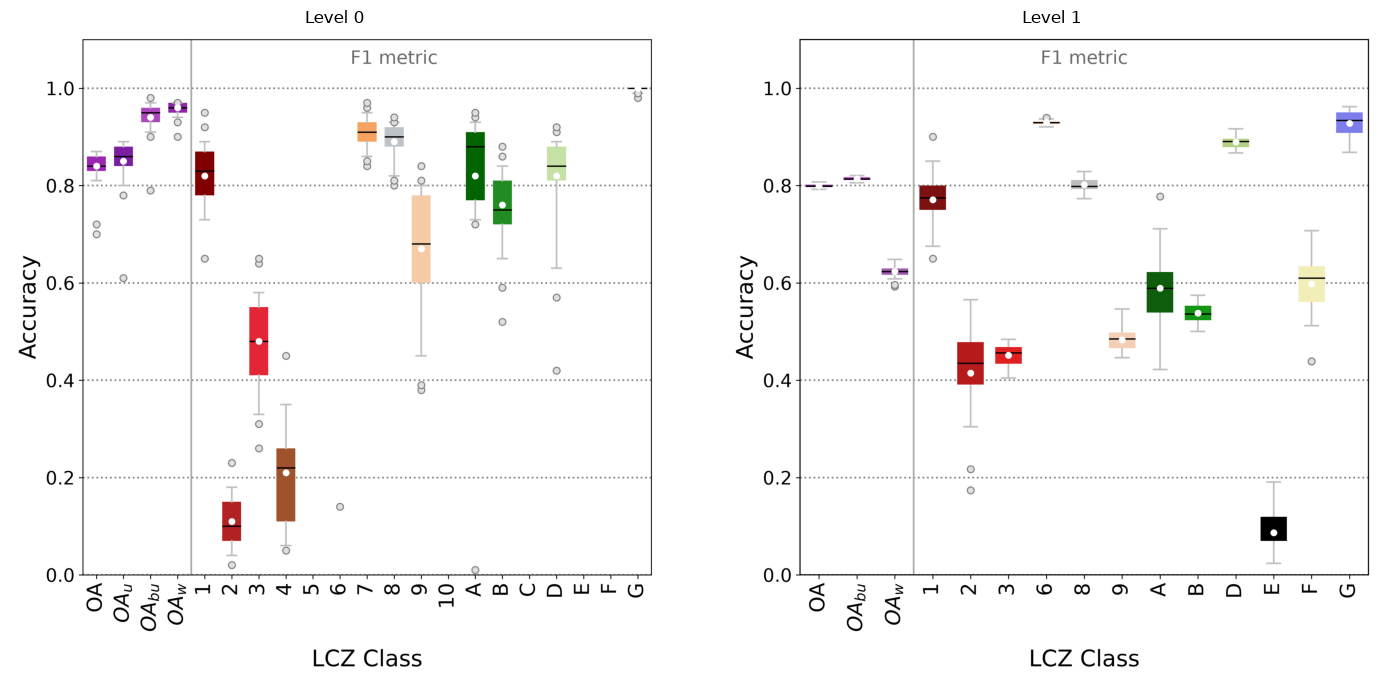

In [84]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

output_dir = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures")

fig0 = output_dir / "level0_accuracy_F1_metric.png"
fig1 = output_dir / "level1_accuracy_F1_metric.png"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.92,
    bottom=0.05,
    wspace=0.02
)
for ax, path, title in zip(axes, [fig0, fig1], ["Level 0", "Level 1"]):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
# Save the figure
output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'level0_level1_accuracy_F1_metric.png'), dpi=300, bbox_inches='tight')

plt.show()

In [64]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=variables
).sort_values(ascending=False)

print(importance)

per_impervious       0.204722
per_total_grass      0.180546
wall_plan_area_m2    0.155633
height               0.150425
svf                  0.147681
per_tree             0.122102
per_water            0.038891
dtype: float64


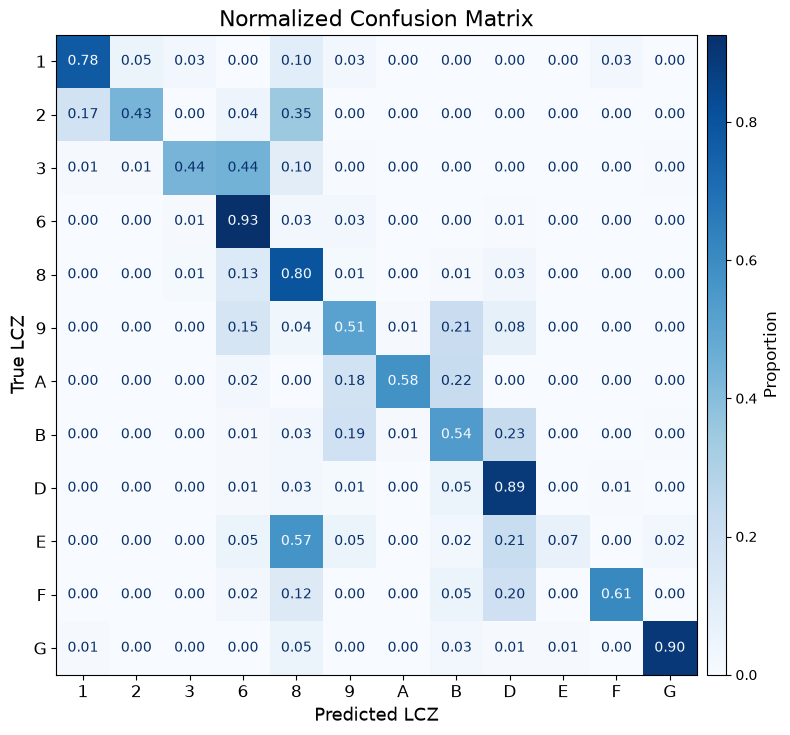

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

cm = confusion_matrix(y_test, pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format=".2f",
    xticks_rotation=45,
    colorbar=False  # IMPORTANT: turn off default colorbar
)

ax.set_xticklabels(
    [lcz_label_map.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()],
    rotation=0,
    ha='center',
    fontsize=12
)

ax.set_yticklabels(
    [lcz_label_map.get(int(t.get_text()), t.get_text()) for t in ax.get_yticklabels()],
    rotation=0,
    fontsize=12
)

# ✔️ Create properly aligned colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cbar = fig.colorbar(disp.im_, cax=cax)
cbar.set_label('Proportion', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title('Normalized Confusion Matrix', fontsize=16)
ax.set_xlabel('Predicted LCZ', fontsize=13)
ax.set_ylabel('True LCZ', fontsize=13)

plt.tight_layout()

# export the confusion matrix figure
# Save the figure
output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'level1_confusion_matrix.png'), dpi=300, bbox_inches='tight')

plt.show()

# 4 Assessing the Consistency of LCZ Classification
**Objective**
Check whether your LCZ (Local Climate Zone) classification is consistent with the underlying physical characteristics

1. Join Land cover and building parameters
2. Compare the distributions of variables by LCZ
3. Random Forest classification
4. Feature importance
5. Confusion matrix